# TMDB Movie Data Analysis using Pandas and APIs
**Step 1: API Data Extraction & Step 2: Data Cleaning & Transformation**

This notebook fetches movie data from the TMDb API, cleans it, and prepares it for KPI analysis (Step 3) and visualization (Step 4).

## Step 0: Load API credentials
API key is stored in a `.env` file at the project root (never hardcoded, never committed to Git).

In [1]:
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path="../.env")
api_key = os.getenv("TMDB_API_KEY")
print("Key loaded:", api_key is not None)


Key loaded: True


## Step 1: Fetch Movie Data from API
First, a single test call to inspect the raw JSON shape before looping over all movie IDs.

In [2]:
import requests

movie_id = 597  # Titanic
url = f"https://api.themoviedb.org/3/movie/{movie_id}"
params = {"api_key": api_key, "language": "en-US"}

response = requests.get(url, params=params)
print("Status code:", response.status_code)

data = response.json()
data


Status code: 200


{'adult': False,
 'backdrop_path': '/xnHVX37XZEp33hhCbYlQFq7ux1J.jpg',
 'belongs_to_collection': None,
 'budget': 200000000,
 'genres': [{'id': 18, 'name': 'Drama'}, {'id': 10749, 'name': 'Romance'}],
 'homepage': 'https://www.paramountmovies.com/movies/titanic',
 'id': 597,
 'imdb_id': 'tt0120338',
 'origin_country': ['US'],
 'original_language': 'en',
 'original_title': 'Titanic',
 'overview': "101-year-old Rose DeWitt Bukater tells the story of her life aboard the Titanic, 84 years later. A young Rose boards the ship with her mother and fiancé. Meanwhile, Jack Dawson and Fabrizio De Rossi win third-class tickets aboard the ship. Rose tells the whole story from Titanic's departure through to its death—on its first and last voyage—on April 15, 1912.",
 'popularity': 24.0259,
 'poster_path': '/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg',
 'production_companies': [{'id': 4,
   'logo_path': '/jay6WcMgagAklUt7i9Euwj1pzTF.png',
   'name': 'Paramount Pictures',
   'origin_country': 'US'},
  {'id': 25,

### Fetch all 19 movie IDs from the project brief
Failures (e.g. invalid IDs) are tracked separately instead of crashing the whole fetch.

In [3]:
import pandas as pd

movie_ids = [
    0, 299534, 19995, 140607, 299536, 597, 135397,
    420818, 24428, 168259, 99861, 284054, 12445,
    181808, 330457, 351286, 109445, 321612, 260513
]

movies_data = []
failed_ids = []

for mid in movie_ids:
    url = f"https://api.themoviedb.org/3/movie/{mid}"
    params = {"api_key": api_key, "language": "en-US"}
    response = requests.get(url, params=params)

    if response.status_code == 200:
        movies_data.append(response.json())
    else:
        print(f"Failed to fetch movie_id {mid}: status {response.status_code}")
        failed_ids.append(mid)

print(f"\nSuccessfully fetched {len(movies_data)} out of {len(movie_ids)} movies.")

raw_df = pd.DataFrame(movies_data)
raw_df.head()


Failed to fetch movie_id 0: status 404



Successfully fetched 18 out of 19 movies.


,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,revenue,runtime,softcore,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",356000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,...,2799439100,181,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Avenge the fallen.,Avengers: Endgame,False,8.239,28060
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,...,2923706026,162,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Enter the world of Pandora.,Avatar,False,7.609,34246
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,"{'id': 10, 'name': 'Star Wars Collection', 'po...",245000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,...,2068223624,136,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.248,20667
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",300000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,...,2052415039,149,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.239,32319
4,False,/xnHVX37XZEp33hhCbYlQFq7ux1J.jpg,None,200000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,...,2264162353,194,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Nothing on earth could come between them.,Titanic,False,7.902,27372


## Step 2: Data Cleaning and Preprocessing
### Drop irrelevant columns
`raw_df` is kept untouched as the original fetch result; `df` becomes the working copy.

In [4]:
columns_to_drop = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']

df = raw_df.drop(columns=columns_to_drop)

print(f"Columns before: {raw_df.shape[1]}, Columns after: {df.shape[1]}")
df.head()


Columns before: 27, Columns after: 22


,backdrop_path,belongs_to_collection,budget,genres,id,origin_country,original_language,overview,popularity,poster_path,...,release_date,revenue,runtime,softcore,spoken_languages,status,tagline,title,vote_average,vote_count
0,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",356000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",299534,[US],en,After the devastating events of Avengers: Infi...,25.0712,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,...,2019-04-24,2799439100,181,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Avenge the fallen.,Avengers: Endgame,8.239,28060
1,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",19995,[US],en,"In the 22nd century, a paraplegic Marine is di...",17.4200,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,...,2009-12-16,2923706026,162,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Enter the world of Pandora.,Avatar,7.609,34246
2,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,"{'id': 10, 'name': 'Star Wars Collection', 'po...",245000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",140607,[US],en,Thirty years after defeating the Galactic Empi...,12.1438,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,...,2015-12-15,2068223624,136,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Every generation has a story.,Star Wars: The Force Awakens,7.248,20667
3,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",300000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",299536,[US],en,As the Avengers and their allies have continue...,35.8921,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,...,2018-04-25,2052415039,149,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Destiny arrives all the same.,Avengers: Infinity War,8.239,32319
4,/xnHVX37XZEp33hhCbYlQFq7ux1J.jpg,None,200000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",597,[US],en,101-year-old Rose DeWitt Bukater tells the sto...,24.0259,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,...,1997-12-18,2264162353,194,False,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Nothing on earth could come between them.,Titanic,7.902,27372


### Investigate and drop the undocumented `softcore` field
Not found in any official TMDb documentation. Behaves like `adult` (boolean content flag, `False` for every movie here) — irrelevant to financial/performance analysis, so it's dropped.

In [5]:
if 'softcore' in df.columns:
    df = df.drop(columns=['softcore'])
print(f"Columns now: {df.shape[1]}")


Columns now: 21


### Extract JSON-nested columns into clean, readable strings
`genres`, `production_companies`, `production_countries`, and `spoken_languages` are all lists of dictionaries. Each is reduced to a single `|`-separated string of names.

In [6]:
def extract_genre_names(genre_list):
    if isinstance(genre_list, list):
        return "|".join([g['name'] for g in genre_list])
    return None

df['genres'] = df['genres'].apply(extract_genre_names)
df['genres'].head()


0    Adventure|Science Fiction|Action
1    Science Fiction|Action|Adventure
2    Adventure|Action|Science Fiction
3    Adventure|Action|Science Fiction
4                       Drama|Romance
Name: genres, dtype: str

In [7]:
def extract_names(item_list):
    if isinstance(item_list, list):
        return "|".join([item['name'] for item in item_list])
    return None

df['production_companies'] = df['production_companies'].apply(extract_names)
df['production_countries'] = df['production_countries'].apply(extract_names)
df['spoken_languages'] = df['spoken_languages'].apply(extract_names)


`belongs_to_collection` is a single dictionary (or `None`), not a list — handled with `.get('name')` so a missing key never raises an error.

In [8]:
def extract_collection_name(collection):
    if isinstance(collection, dict):
        return collection.get('name')
    return None

df['belongs_to_collection'] = df['belongs_to_collection'].apply(extract_collection_name)


`origin_country` is a plain list of country codes (no nested dictionaries) — joined directly.

In [9]:
df['origin_country'] = df['origin_country'].apply(lambda c: "|".join(c) if isinstance(c, list) else c)
df['origin_country'].head()


0    US
1    US
2    US
3    US
4    US
Name: origin_country, dtype: str

In [10]:
df[['genres', 'belongs_to_collection', 'production_companies',
    'production_countries', 'spoken_languages']].head()


,genres,belongs_to_collection,production_companies,production_countries,spoken_languages
0,Adventure|Science Fiction|Action,The Avengers Collection,Marvel Studios,United States of America,English|日本語|
1,Science Fiction|Action|Adventure,Avatar Collection,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,English|Español
2,Adventure|Action|Science Fiction,Star Wars Collection,Lucasfilm Ltd.|Bad Robot,United States of America,English
3,Adventure|Action|Science Fiction,The Avengers Collection,Marvel Studios,United States of America,English|
4,Drama|Romance,NaN,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,English|Français|Deutsch|svenska|Italiano|Pусский


### Convert data types
`errors='coerce'` converts unparseable values to `NaN`/`NaT` instead of crashing.

In [11]:
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['id'] = pd.to_numeric(df['id'], errors='coerce')
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

df[['budget', 'id', 'popularity']].dtypes


budget          int64
id              int64
popularity    float64
dtype: object

In [12]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_date'].head()


0   2019-04-24
1   2009-12-16
2   2015-12-15
3   2018-04-25
4   1997-12-18
Name: release_date, dtype: datetime64[us]

### Replace unrealistic zero values
A budget/revenue/runtime of exactly `0` is not physically plausible for a real released movie — it signals missing data, not a true value of zero.

In [13]:
import numpy as np

df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)
df['runtime'] = df['runtime'].replace(0, np.nan)

print("Missing budget:", df['budget'].isna().sum())
print("Missing revenue:", df['revenue'].isna().sum())
print("Missing runtime:", df['runtime'].isna().sum())


Missing budget: 0
Missing revenue: 0
Missing runtime: 0


### Convert budget & revenue to million USD

In [14]:
df['budget_musd'] = df['budget'] / 1_000_000
df['revenue_musd'] = df['revenue'] / 1_000_000

df[['title', 'budget_musd', 'revenue_musd']].head()


,title,budget_musd,revenue_musd
0,Avengers: Endgame,356.0,2799.439100
1,Avatar,237.0,2923.706026
2,Star Wars: The Force Awakens,245.0,2068.223624
3,Avengers: Infinity War,300.0,2052.415039
4,Titanic,200.0,2264.162353


### Check for `vote_count = 0` anomalies
If `vote_count` is 0, `vote_average` has no real data behind it and should be treated as missing.

In [15]:
zero_votes = df[df['vote_count'] == 0]
print(f"Movies with 0 vote_count: {len(zero_votes)}")
zero_votes[['title', 'vote_count', 'vote_average']]


Movies with 0 vote_count: 0


,title,vote_count,vote_average


In [16]:
df.loc[df['vote_count'] == 0, 'vote_average'] = np.nan


### Check for placeholder text in `overview` / `tagline`

In [17]:
print(df['overview'].value_counts().head(10))
print(df['tagline'].value_counts().head(10))


overview
After the devastating events of Avengers: Infinity War, the universe is in ruins due to the efforts of the Mad Titan, Thanos. With the help of remaining allies, the Avengers must assemble once more in order to undo Thanos' actions and restore order to the universe once and for all, no matter what consequences may be in store.                                                                                                                                                                       1
In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.                                                                                                                                                                                                                                                                                                                               1

In [18]:
df['overview'] = df['overview'].replace('No Data', np.nan)
df['tagline'] = df['tagline'].replace('No Data', np.nan)


### Remove duplicates and rows with unknown `id` / `title`

In [19]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing id:", df['id'].isna().sum())
print("Missing title:", df['title'].isna().sum())

df = df.drop_duplicates()
df = df.dropna(subset=['id', 'title'])


Duplicate rows: 0
Missing id: 0
Missing title: 0


### Keep only rows with at least 10 non-NaN columns

In [20]:
non_null_counts = df.notna().sum(axis=1)
print(non_null_counts.sort_values())

df = df[non_null_counts >= 10]
print(f"Rows remaining: {len(df)}")


4     23
16    23
2     24
0     24
3     24
5     24
6     24
1     24
8     24
9     24
10    24
11    24
12    24
13    24
14    24
7     24
15    24
17    24
dtype: int64
Rows remaining: 18


### Filter to 'Released' movies only, then drop `status`

In [21]:
print(df['status'].value_counts())


status
Released    18
Name: count, dtype: int64


In [22]:
df = df[df['status'] == 'Released']
df = df.drop(columns=['status'])
print(f"Rows remaining: {len(df)}")
print(f"Columns remaining: {df.shape[1]}")


Rows remaining: 18
Columns remaining: 23


### Fetch cast & crew (credits endpoint)
`cast`, `cast_size`, `director`, and `crew_size` don't exist in the `/movie/{id}` response — they come from a separate endpoint: `/movie/{id}/credits`. One more API call per movie, following the exact same pattern as Step 1.

The response shape: a dictionary with `'cast'` (list of actor dicts, each with a `'name'`) and `'crew'` (list of crew dicts, each with a `'name'` and a `'job'` — e.g. `"Director"`).

In [23]:
credits_data = {}   # movie_id -> credits dict
failed_credit_ids = []

for mid in df['id']:
    url = f"https://api.themoviedb.org/3/movie/{mid}/credits"
    params = {"api_key": api_key, "language": "en-US"}
    response = requests.get(url, params=params)

    if response.status_code == 200:
        credits_data[mid] = response.json()
    else:
        print(f"Failed to fetch credits for movie_id {mid}: status {response.status_code}")
        failed_credit_ids.append(mid)

print(f"Successfully fetched credits for {len(credits_data)} out of {len(df)} movies.")


Successfully fetched credits for 18 out of 18 movies.


Extract the four fields we need from each movie's credits dictionary:
- `cast`: top 10 billed actor names, joined with `|`
- `cast_size`: total number of cast members listed
- `director`: name of the crew member whose `job` is `"Director"`
- `crew_size`: total number of crew members listed

In [24]:
def get_cast_string(credits, top_n=10):
    cast_list = credits.get('cast', [])
    names = [person['name'] for person in cast_list[:top_n]]
    return "|".join(names) if names else None

def get_cast_size(credits):
    return len(credits.get('cast', []))

def get_director(credits):
    crew_list = credits.get('crew', [])
    for person in crew_list:
        if person.get('job') == 'Director':
            return person['name']
    return None

def get_crew_size(credits):
    return len(credits.get('crew', []))

df['cast'] = df['id'].map(lambda mid: get_cast_string(credits_data[mid]) if mid in credits_data else None)
df['cast_size'] = df['id'].map(lambda mid: get_cast_size(credits_data[mid]) if mid in credits_data else None)
df['director'] = df['id'].map(lambda mid: get_director(credits_data[mid]) if mid in credits_data else None)
df['crew_size'] = df['id'].map(lambda mid: get_crew_size(credits_data[mid]) if mid in credits_data else None)

df[['title', 'director', 'cast_size', 'crew_size']].head()


,title,director,cast_size,crew_size
0,Avengers: Endgame,Anthony Russo,105,613
1,Avatar,James Cameron,67,999
2,Star Wars: The Force Awakens,J.J. Abrams,99,269
3,Avengers: Infinity War,Joe Russo,69,736
4,Titanic,James Cameron,117,270


**Why `.map()` here, not a `for` loop or `.apply()` across the whole row?** `credits_data` is keyed by movie `id`, not by row position — `.map()` is the right tool for "look up a value for each entry in this column, using an external dictionary/function," which is exactly this case.

### Reorder columns & reset index

In [25]:
final_columns = [
    'id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection',
    'original_language', 'budget_musd', 'revenue_musd', 'production_companies',
    'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime',
    'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 'crew_size'
]

df = df[final_columns]
df = df.reset_index(drop=True)

df.shape


(18, 22)

### Save the cleaned dataset
Persist the cleaned DataFrame so Step 3 (KPI analysis) can load it directly, without re-fetching from the API every time.

In [26]:
df.to_csv("../data/processed/tmdb_movies_clean.csv", index=False)
print("Saved to ../data/processed/tmdb_movies_clean.csv")
df.head()

Saved to ../data/processed/tmdb_movies_clean.csv


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,299534,Avengers: Endgame,Avenge the fallen.,2019-04-24,Adventure|Science Fiction|Action,The Avengers Collection,en,356.0,2799.439100,Marvel Studios,...,8.239,25.0712,181,After the devastating events of Avengers: Infi...,English|日本語|,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo,613
1,19995,Avatar,Enter the world of Pandora.,2009-12-16,Science Fiction|Action|Adventure,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,7.609,17.4200,162,"In the 22nd century, a paraplegic Marine is di...",English|Español,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999
2,140607,Star Wars: The Force Awakens,Every generation has a story.,2015-12-15,Adventure|Action|Science Fiction,Star Wars Collection,en,245.0,2068.223624,Lucasfilm Ltd.|Bad Robot,...,7.248,12.1438,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,269
3,299536,Avengers: Infinity War,Destiny arrives all the same.,2018-04-25,Adventure|Action|Science Fiction,The Avengers Collection,en,300.0,2052.415039,Marvel Studios,...,8.239,35.8921,149,As the Avengers and their allies have continue...,English|,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Joe Russo,736
4,597,Titanic,Nothing on earth could come between them.,1997-12-18,Drama|Romance,NaN,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,...,7.902,24.0259,194,101-year-old Rose DeWitt Bukater tells the sto...,English|Français|Deutsch|svenska|Italiano|Pусский,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,117,James Cameron,270


## Step 3: KPI Implementation & Analysis

### Best/Worst Performing Movies
Starting with the simplest ranking — highest revenue — before generalizing into a reusable function.

In [27]:
df.sort_values('revenue_musd', ascending=False).head(5)[['title', 'revenue_musd']]

,title,revenue_musd
1,Avatar,2923.706026
0,Avengers: Endgame,2799.439100
4,Titanic,2264.162353
2,Star Wars: The Force Awakens,2068.223624
3,Avengers: Infinity War,2052.415039


### A reusable ranking function (UDF)

Rather than repeating `.sort_values().head()` eight separate times for every KPI (revenue, budget, profit, ROI, votes, ratings, popularity), one function handles them all. `min_budget` anticipates the brief's ROI requirement ("only movies with Budget ≥ 10M").

In [28]:
def top_movies(dataframe, column, n=5, ascending=False, min_budget=None):
    """
    Returns the top (or bottom) n movies ranked by a given column.
    
    dataframe   : the DataFrame to rank
    column      : which column to sort by (e.g. 'revenue_musd')
    n           : how many rows to return
    ascending   : False = highest first, True = lowest first
    min_budget  : optional filter, e.g. only movies with budget >= 10 (million)
    """
    data = dataframe.copy()
    
    if min_budget is not None:
        data = data[data['budget_musd'] >= min_budget]
    
    return data.sort_values(column, ascending=ascending).head(n)[['title', column]]

### Applying the UDF to every KPI

Each ranking is now a single, readable line. Note: "Lowest Rated" filters to `vote_count >= 10` *before* calling the function — a vote-count filter is a different concern from the budget filter built into `top_movies()`, so it's kept separate rather than overloading one function with every possible filter type.

In [29]:
# Highest Revenue
print(top_movies(df, 'revenue_musd', n=5))

# Highest Budget
print(top_movies(df, 'budget_musd', n=5))

# Most Voted
print(top_movies(df, 'vote_count', n=5))

# Highest Rated
print(top_movies(df, 'vote_average', n=5))

# Lowest Rated (only movies with >= 10 votes, per your brief)
low_rated = df[df['vote_count'] >= 10]
print(top_movies(low_rated, 'vote_average', n=5, ascending=True))

# Most Popular
print(top_movies(df, 'popularity', n=5))

                          title  revenue_musd
1                        Avatar   2923.706026
0             Avengers: Endgame   2799.439100
4                       Titanic   2264.162353
2  Star Wars: The Force Awakens   2068.223624
3        Avengers: Infinity War   2052.415039
                           title  budget_musd
0              Avengers: Endgame        356.0
3         Avengers: Infinity War        300.0
12      Star Wars: The Last Jedi        300.0
6                  The Lion King        260.0
2   Star Wars: The Force Awakens        245.0
                    title  vote_count
7            The Avengers       38814
1                  Avatar       34246
3  Avengers: Infinity War       32319
0       Avengers: Endgame       28060
4                 Titanic       27372
                                           title  vote_average
0                              Avengers: Endgame         8.239
3                         Avengers: Infinity War         8.239
11  Harry Potter and the Deathl

### Profit and ROI

`profit_musd` and `roi` don't exist yet — calculated here with direct vectorized arithmetic (fastest option, no custom logic needed) before ranking. ROI rankings are restricted to movies with `budget_musd >= 10` per the project brief, using the `min_budget` parameter built into the UDF.

In [30]:
df['profit_musd'] = df['revenue_musd'] - df['budget_musd']
df['roi'] = df['revenue_musd'] / df['budget_musd']

# Highest Profit
print(top_movies(df, 'profit_musd', n=5))

# Lowest Profit
print(top_movies(df, 'profit_musd', n=5, ascending=True))

# Highest ROI (only budget >= 10M)
print(top_movies(df, 'roi', n=5, min_budget=10))

# Lowest ROI (only budget >= 10M)
print(top_movies(df, 'roi', n=5, ascending=True, min_budget=10))

                          title  profit_musd
1                        Avatar  2686.706026
0             Avengers: Endgame  2443.439100
4                       Titanic  2064.162353
2  Star Wars: The Force Awakens  1823.223624
3        Avengers: Infinity War  1752.415039
                             title  profit_musd
12        Star Wars: The Last Jedi  1034.407706
17                   Incredibles 2  1043.225667
16            Beauty and the Beast  1106.115964
15                          Frozen  1124.219009
14  Jurassic World: Fallen Kingdom  1140.469037
                                           title        roi
1                                         Avatar  12.336312
4                                        Titanic  11.320812
5                                 Jurassic World  11.143583
11  Harry Potter and the Deathly Hallows: Part 2  10.732090
13                                     Frozen II   9.691223
                       title       roi
12  Star Wars: The Last Jedi  4.448026
9   

### Advanced Movie Filtering & Search Queries

**Caveat on this dataset:** the 18 movies fetched are all specific blockbuster franchise entries chosen in the project brief (Avengers, Avatar, Star Wars, Titanic, Jurassic World, etc.). Niche queries like "Bruce Willis sci-fi" or "Tarantino/Uma Thurman" (e.g. *Die Hard*, *Pulp Fiction*) were never fetched, so both searches below are expected to return **zero rows** on this particular dataset — that's a property of which 19 IDs the brief specifies, not a bug in the filtering logic. The code is written to work correctly on any larger dataset (e.g. the full TMDb catalog).

In [31]:
# Search 1: best-rated Science Fiction Action movies starring Bruce Willis
search_1 = df[
    df['genres'].str.contains('Science Fiction', na=False)
    & df['genres'].str.contains('Action', na=False)
    & df['cast'].str.contains('Bruce Willis', na=False)
].sort_values('vote_average', ascending=False)

print(f"Matches: {len(search_1)}")
search_1[['title', 'genres', 'vote_average', 'cast']]

Matches: 0


,title,genres,vote_average,cast


In [32]:
# Search 2: movies starring Uma Thurman, directed by Quentin Tarantino, shortest runtime first
search_2 = df[
    df['cast'].str.contains('Uma Thurman', na=False)
    & (df['director'] == 'Quentin Tarantino')
].sort_values('runtime', ascending=True)

print(f"Matches: {len(search_2)}")
search_2[['title', 'director', 'runtime', 'cast']]

Matches: 0


,title,director,runtime,cast


### Franchise vs. Standalone Movie Performance

A movie is treated as part of a franchise if `belongs_to_collection` is not null. Comparing the two groups on mean revenue, median ROI, mean budget, mean popularity, and mean rating.

In [33]:
df['is_franchise'] = df['belongs_to_collection'].notna()

franchise_vs_standalone = df.groupby('is_franchise').agg(
    n_movies=('title', 'count'),
    mean_revenue_musd=('revenue_musd', 'mean'),
    median_roi=('roi', 'median'),
    mean_budget_musd=('budget_musd', 'mean'),
    mean_popularity=('popularity', 'mean'),
    mean_rating=('vote_average', 'mean'),
)
franchise_vs_standalone.index = franchise_vs_standalone.index.map({True: 'Franchise', False: 'Standalone'})
franchise_vs_standalone.index.name = 'group'

franchise_vs_standalone

,n_movies,mean_revenue_musd,median_roi,mean_budget_musd,mean_popularity,mean_rating
group,,,,,,
Standalone,2,1765.139159,9.617018,180.0,17.968350,7.434500
Franchise,16,1682.775216,7.786117,218.0,19.338838,7.396438


### Most Successful Movie Franchises

Grouped by `belongs_to_collection`, ranked by total revenue.

In [34]:
franchise_success = df[df['belongs_to_collection'].notna()].groupby('belongs_to_collection').agg(
    n_movies=('title', 'count'),
    total_budget_musd=('budget_musd', 'sum'),
    mean_budget_musd=('budget_musd', 'mean'),
    total_revenue_musd=('revenue_musd', 'sum'),
    mean_revenue_musd=('revenue_musd', 'mean'),
    mean_rating=('vote_average', 'mean'),
).sort_values('total_revenue_musd', ascending=False)

franchise_success

,n_movies,total_budget_musd,mean_budget_musd,total_revenue_musd,mean_revenue_musd,mean_rating
belongs_to_collection,,,,,,
The Avengers Collection,4,1111.0,277.75,7776.073348,1944.018337,7.9525
Star Wars Collection,2,545.0,272.50,3402.631330,1701.315665,6.9975
Jurassic Park Collection,2,320.0,160.00,2982.006481,1491.003241,6.6170
Avatar Collection,1,237.0,237.00,2923.706026,2923.706026,7.6090
Frozen Collection,2,300.0,150.00,2727.902485,1363.951242,7.2390
The Lion King (Reboot) Collection,1,260.0,260.00,1662.020819,1662.020819,7.1000
The Fast and the Furious Collection,1,190.0,190.00,1515.400000,1515.400000,7.2180
Black Panther Collection,1,200.0,200.00,1349.926083,1349.926083,7.3640
Harry Potter Collection,1,125.0,125.00,1341.511219,1341.511219,8.0810


### Most Successful Directors

Grouped by `director`, ranked by total revenue.

In [35]:
director_success = df.groupby('director').agg(
    n_movies=('title', 'count'),
    total_revenue_musd=('revenue_musd', 'sum'),
    mean_rating=('vote_average', 'mean'),
).sort_values('total_revenue_musd', ascending=False)

director_success

,n_movies,total_revenue_musd,mean_rating
director,,,
James Cameron,2,5187.868379,7.7555
Joss Whedon,2,2924.219209,7.6660
Anthony Russo,1,2799.439100,8.2390
J.J. Abrams,1,2068.223624,7.2480
Joe Russo,1,2052.415039,8.2390
Colin Trevorrow,1,1671.537444,6.7030
Jon Favreau,1,1662.020819,7.1000
James Wan,1,1515.400000,7.2180
Jennifer Lee,1,1453.683476,7.2290


## Step 4: Data Visualization

Figures are saved to `../reports/figures/` as PNGs, in addition to being displayed inline. One fixed accent color is used per series/entity throughout (never re-cycled per category), so the same color always means the same thing across charts.

In [36]:
import matplotlib.pyplot as plt

FIGURES_DIR = "../reports/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#444444",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e3e3e3",
    "grid.linewidth": 0.7,
    "font.size": 11,
})

ACCENT = "#2f6f9f"    # single-series charts
ACCENT_B = "#c76a3f"  # second entity in Franchise-vs-Standalone charts

### Revenue vs. Budget

Only the top 5 movies by revenue are directly labeled — labeling all 18 would clutter the plot given how tightly some points cluster.

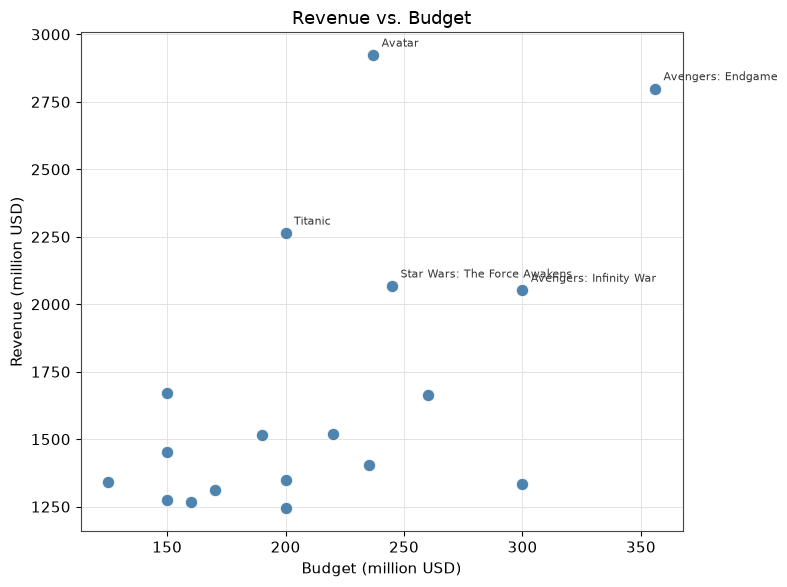

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['budget_musd'], df['revenue_musd'], s=80, color=ACCENT, alpha=0.85,
           edgecolor="white", linewidth=0.8, zorder=3)

top5 = df.nlargest(5, 'revenue_musd')
for _, row in top5.iterrows():
    ax.annotate(row['title'], (row['budget_musd'], row['revenue_musd']),
                fontsize=8, xytext=(6, 6), textcoords='offset points', color="#333333")

ax.set_xlabel("Budget (million USD)")
ax.set_ylabel("Revenue (million USD)")
ax.set_title("Revenue vs. Budget")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/revenue_vs_budget.png", dpi=150)
plt.show()

### ROI Distribution by Genre

Each movie usually has multiple genres (`genres` is `|`-separated), so a movie's ROI counts toward every genre it belongs to — done here with `.explode()`. **Caveat:** with only 18 movies spread across ~10 genres, most genres have just 1-3 data points, so these boxes are illustrative rather than statistically robust.

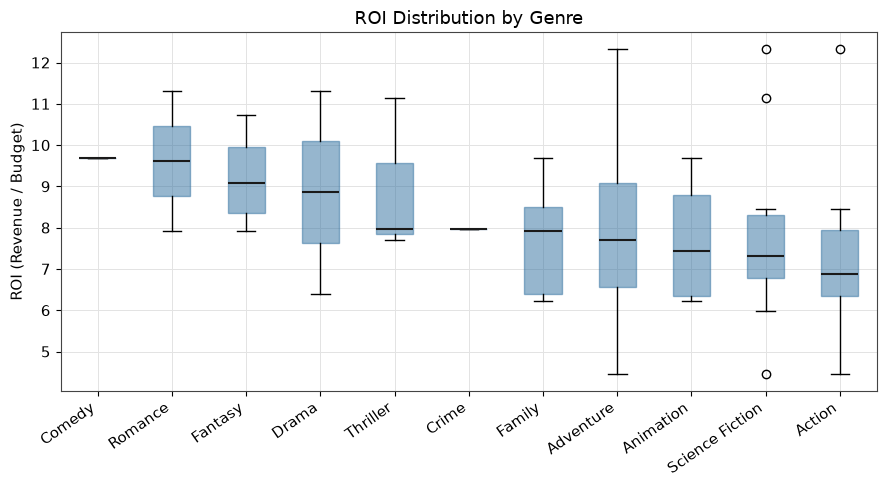

In [38]:
genre_roi = df[['title', 'genres', 'roi']].dropna(subset=['genres', 'roi']).copy()
genre_roi['genres'] = genre_roi['genres'].str.split('|')
genre_roi = genre_roi.explode('genres').rename(columns={'genres': 'genre'})

genre_order = genre_roi.groupby('genre')['roi'].median().sort_values(ascending=False).index
data_by_genre = [genre_roi.loc[genre_roi['genre'] == g, 'roi'].values for g in genre_order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data_by_genre, tick_labels=list(genre_order), patch_artist=True, widths=0.5)

for box in bp['boxes']:
    box.set(facecolor=ACCENT, alpha=0.5, edgecolor=ACCENT)
for median in bp['medians']:
    median.set(color="#1a1a1a", linewidth=1.5)

ax.set_ylabel("ROI (Revenue / Budget)")
ax.set_title("ROI Distribution by Genre")
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/roi_by_genre.png", dpi=150)
plt.show()

### Popularity vs. Rating

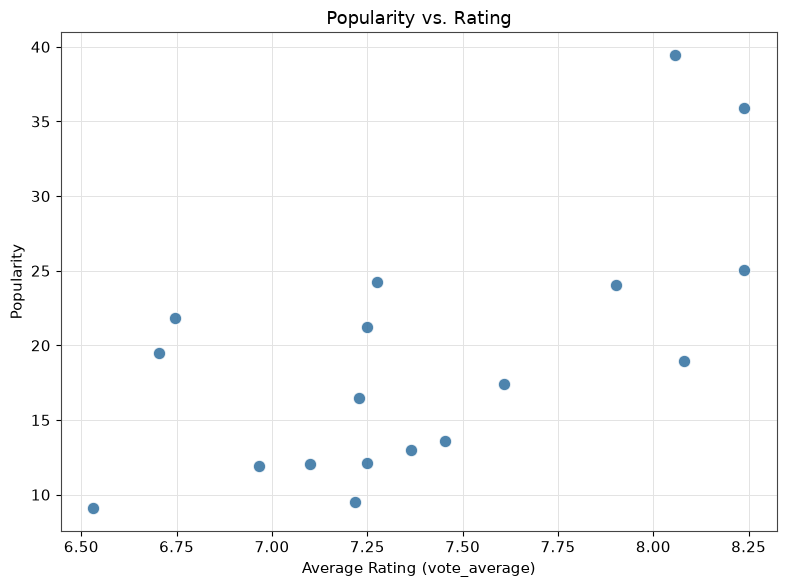

Correlation (rating, popularity): 0.645


In [39]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['vote_average'], df['popularity'], s=80, color=ACCENT, alpha=0.85,
           edgecolor="white", linewidth=0.8, zorder=3)

ax.set_xlabel("Average Rating (vote_average)")
ax.set_ylabel("Popularity")
ax.set_title("Popularity vs. Rating")
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/popularity_vs_rating.png", dpi=150)
plt.show()

print("Correlation (rating, popularity):", df['vote_average'].corr(df['popularity']).round(3))

### Yearly Trends in Box Office Performance

Year is derived on the fly from `release_date` rather than a separate stored column. **Caveat:** these 18 movies are specific hand-picked blockbusters, not a representative sample of each year's full box office — so this chart shows *this dataset's* revenue by year, not the industry's.

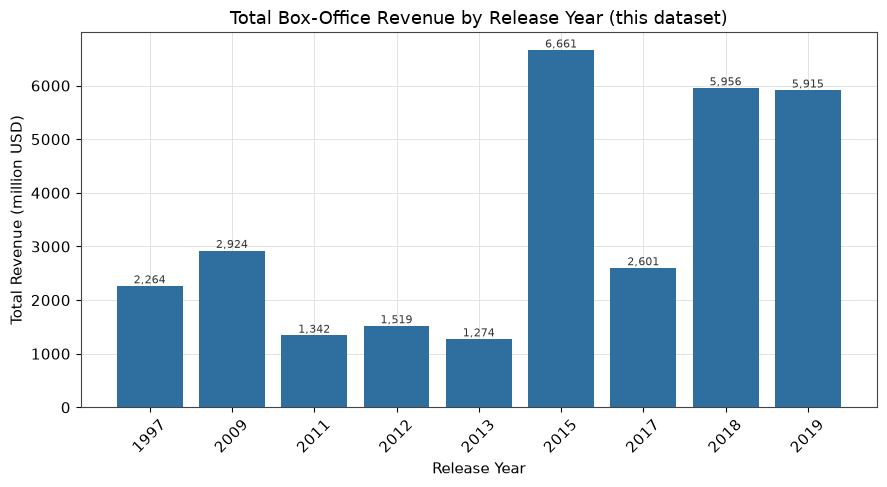

In [40]:
yearly_revenue = (
    df.dropna(subset=['release_date'])
      .groupby(df['release_date'].dt.year)['revenue_musd']
      .sum()
      .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(yearly_revenue.index.astype(str), yearly_revenue.values, color=ACCENT)

for bar, v in zip(bars, yearly_revenue.values):
    ax.annotate(f"{v:,.0f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=8, color="#333333")

ax.set_xlabel("Release Year")
ax.set_ylabel("Total Revenue (million USD)")
ax.set_title("Total Box-Office Revenue by Release Year (this dataset)")
plt.xticks(rotation=45)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/yearly_revenue_trend.png", dpi=150)
plt.show()

### Franchise vs. Standalone: Comparison Across Metrics

The five metrics live on very different scales (revenue in hundreds of millions, rating out of 10), so instead of one bar chart with mismatched axes, this uses small multiples — one subplot per metric, sharing a single color per group (`Franchise` / `Standalone`) across all five.

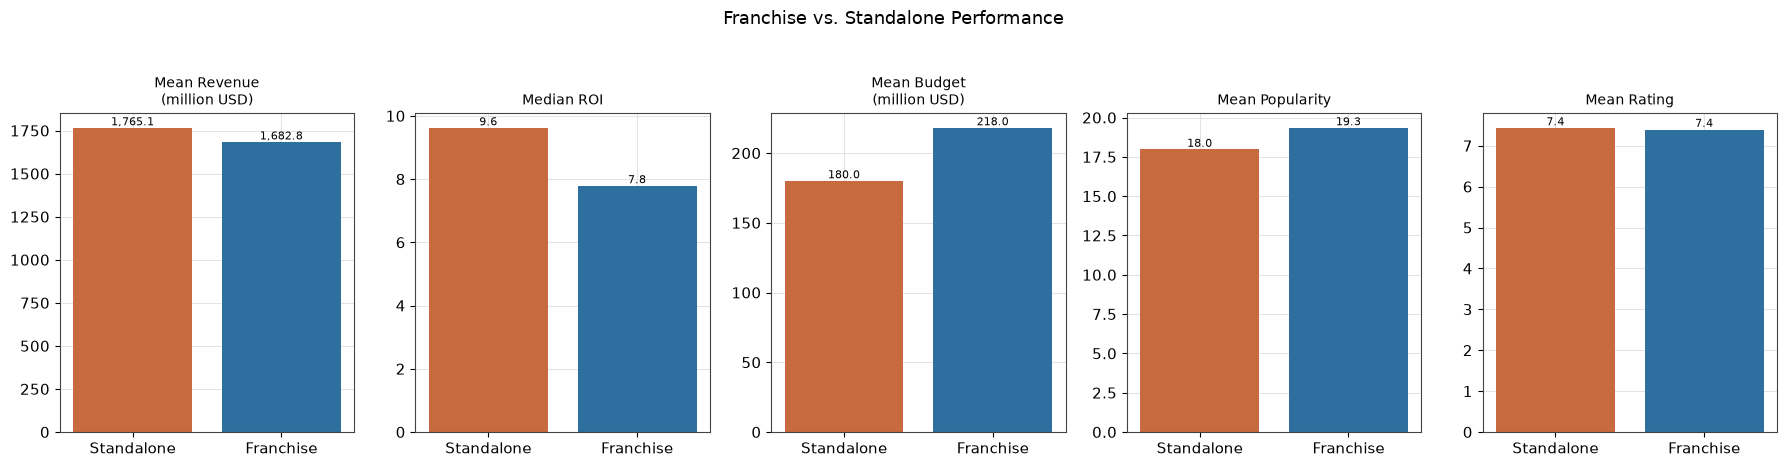

In [41]:
metrics = [
    ('mean_revenue_musd', 'Mean Revenue\n(million USD)'),
    ('median_roi', 'Median ROI'),
    ('mean_budget_musd', 'Mean Budget\n(million USD)'),
    ('mean_popularity', 'Mean Popularity'),
    ('mean_rating', 'Mean Rating'),
]

categories = franchise_vs_standalone.index.tolist()
colors = {'Franchise': ACCENT, 'Standalone': ACCENT_B}

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4.5))
for ax, (col, label) in zip(axes, metrics):
    values = franchise_vs_standalone.loc[categories, col]
    bars = ax.bar(categories, values, color=[colors[c] for c in categories])
    ax.set_title(label, fontsize=10)
    for bar, v in zip(bars, values):
        ax.annotate(f"{v:,.1f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)

fig.suptitle("Franchise vs. Standalone Performance", y=1.03)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/franchise_vs_standalone.png", dpi=150, bbox_inches='tight')
plt.show()

## Key Insights & Conclusions

**Dataset scope.** 19 movie IDs were requested; ID `0` doesn't exist (404) and was skipped, leaving **18 movies** — all major studio blockbusters (Avengers, Star Wars, Avatar, Jurassic World/Park, Frozen, Harry Potter, Black Panther, and similar). This is a curated list, not a random or representative sample, which shapes every finding below.

**Best/worst performers.**
- *Avatar* ($2.92B) and *Avengers: Endgame* ($2.80B) lead on revenue, profit, and are both in the top 3 for ROI (12.3x and among the highest budgets respectively).
- *Avatar*, *Titanic*, and *Jurassic World* have the best ROI (11-12x); *Star Wars: The Last Jedi* has the weakest ROI (4.4x) despite a $300M budget — the only mega-budget title in this set that didn't multiply its budget by double digits.
- *The Avengers* is both the most-voted (38.8k votes) and most popular title, despite not topping revenue — popularity/vote volume and revenue don't move together perfectly here (rating vs. popularity correlation is a moderate **+0.65**).

**Search queries (Bruce Willis sci-fi action; Tarantino/Uma Thurman) both return 0 rows.** This is expected: the 18 fetched IDs are all recent franchise tentpoles, and neither actor/director appears in any of them. The filtering logic itself (genre + cast + director matching) is correct and would return real matches on a broader dataset (e.g. *Die Hard*, *Pulp Fiction*).

**Franchise vs. standalone.** Only 2 of the 18 movies are standalone (*Titanic*, *Beauty and the Beast*) — too few to draw a general conclusion, but directionally in this sample, standalone films actually edge out franchise entries on mean revenue ($1.77B vs $1.68B) and median ROI (9.6x vs 7.8x), while franchise entries needed a larger mean budget ($218M vs $180M) to get there. Ratings and popularity are roughly a wash between the two groups.

**Franchises.** The Avengers Collection is the clear leader — $7.78B total revenue across 4 films and the highest mean rating (7.95) of any multi-film collection. Star Wars ($3.40B, 2 films) and Jurassic Park ($2.98B, 2 films) follow. Harry Potter has only one entry here but posts the single highest franchise rating (8.08).

**Directors.** James Cameron tops total revenue ($5.19B combined from *Avatar* and *Titanic*) despite directing only 2 of the 18 films — both massive hits. Joss Whedon is second ($2.92B, the two Avengers films he directed). The Russo brothers' two Avengers entries share the highest individual rating in the whole dataset (8.239).

**Takeaway.** Within this specific 18-movie set, franchise membership does not guarantee better per-movie economics — it guarantees *volume* (more releases banking on a proven property), while the standout individual results (Avatar, Titanic, the Russo-directed Avengers films) come from a small number of directors/collections executing exceptionally well rather than franchise status alone. Conclusions here describe this dataset, not the global movie market — the underlying code generalizes to a larger TMDb pull if a broader claim is needed.